In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, Conv1D, MaxPooling1D, Flatten

In [ ]:
# Define the file name
zip_path = "/content/creditcard.csv.zip"  # Update the path if needed
# Extract the contents
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")  # Extracts to /content directory
print("Extraction complete.")

Extraction complete.


In [ ]:
df = pd.read_csv("/content/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
#Missing data points
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


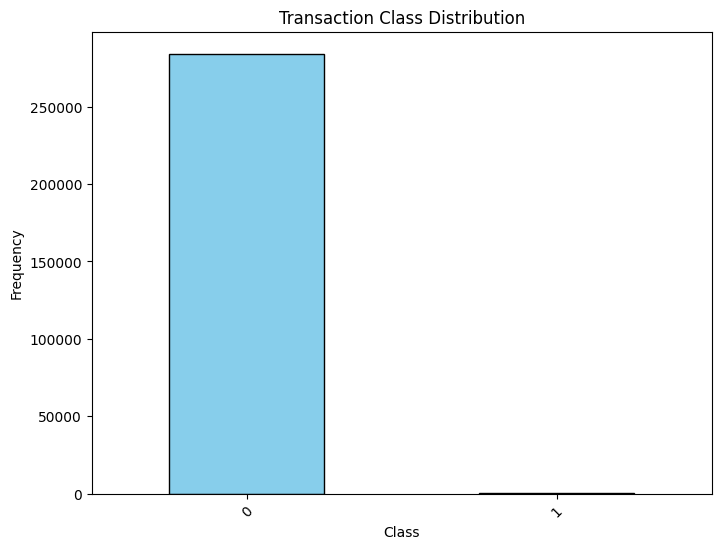

In [ ]:
class_counts = df["Class"].value_counts()

# Plotting the bar plot
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Transaction Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df = df.drop("Time", axis=1)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


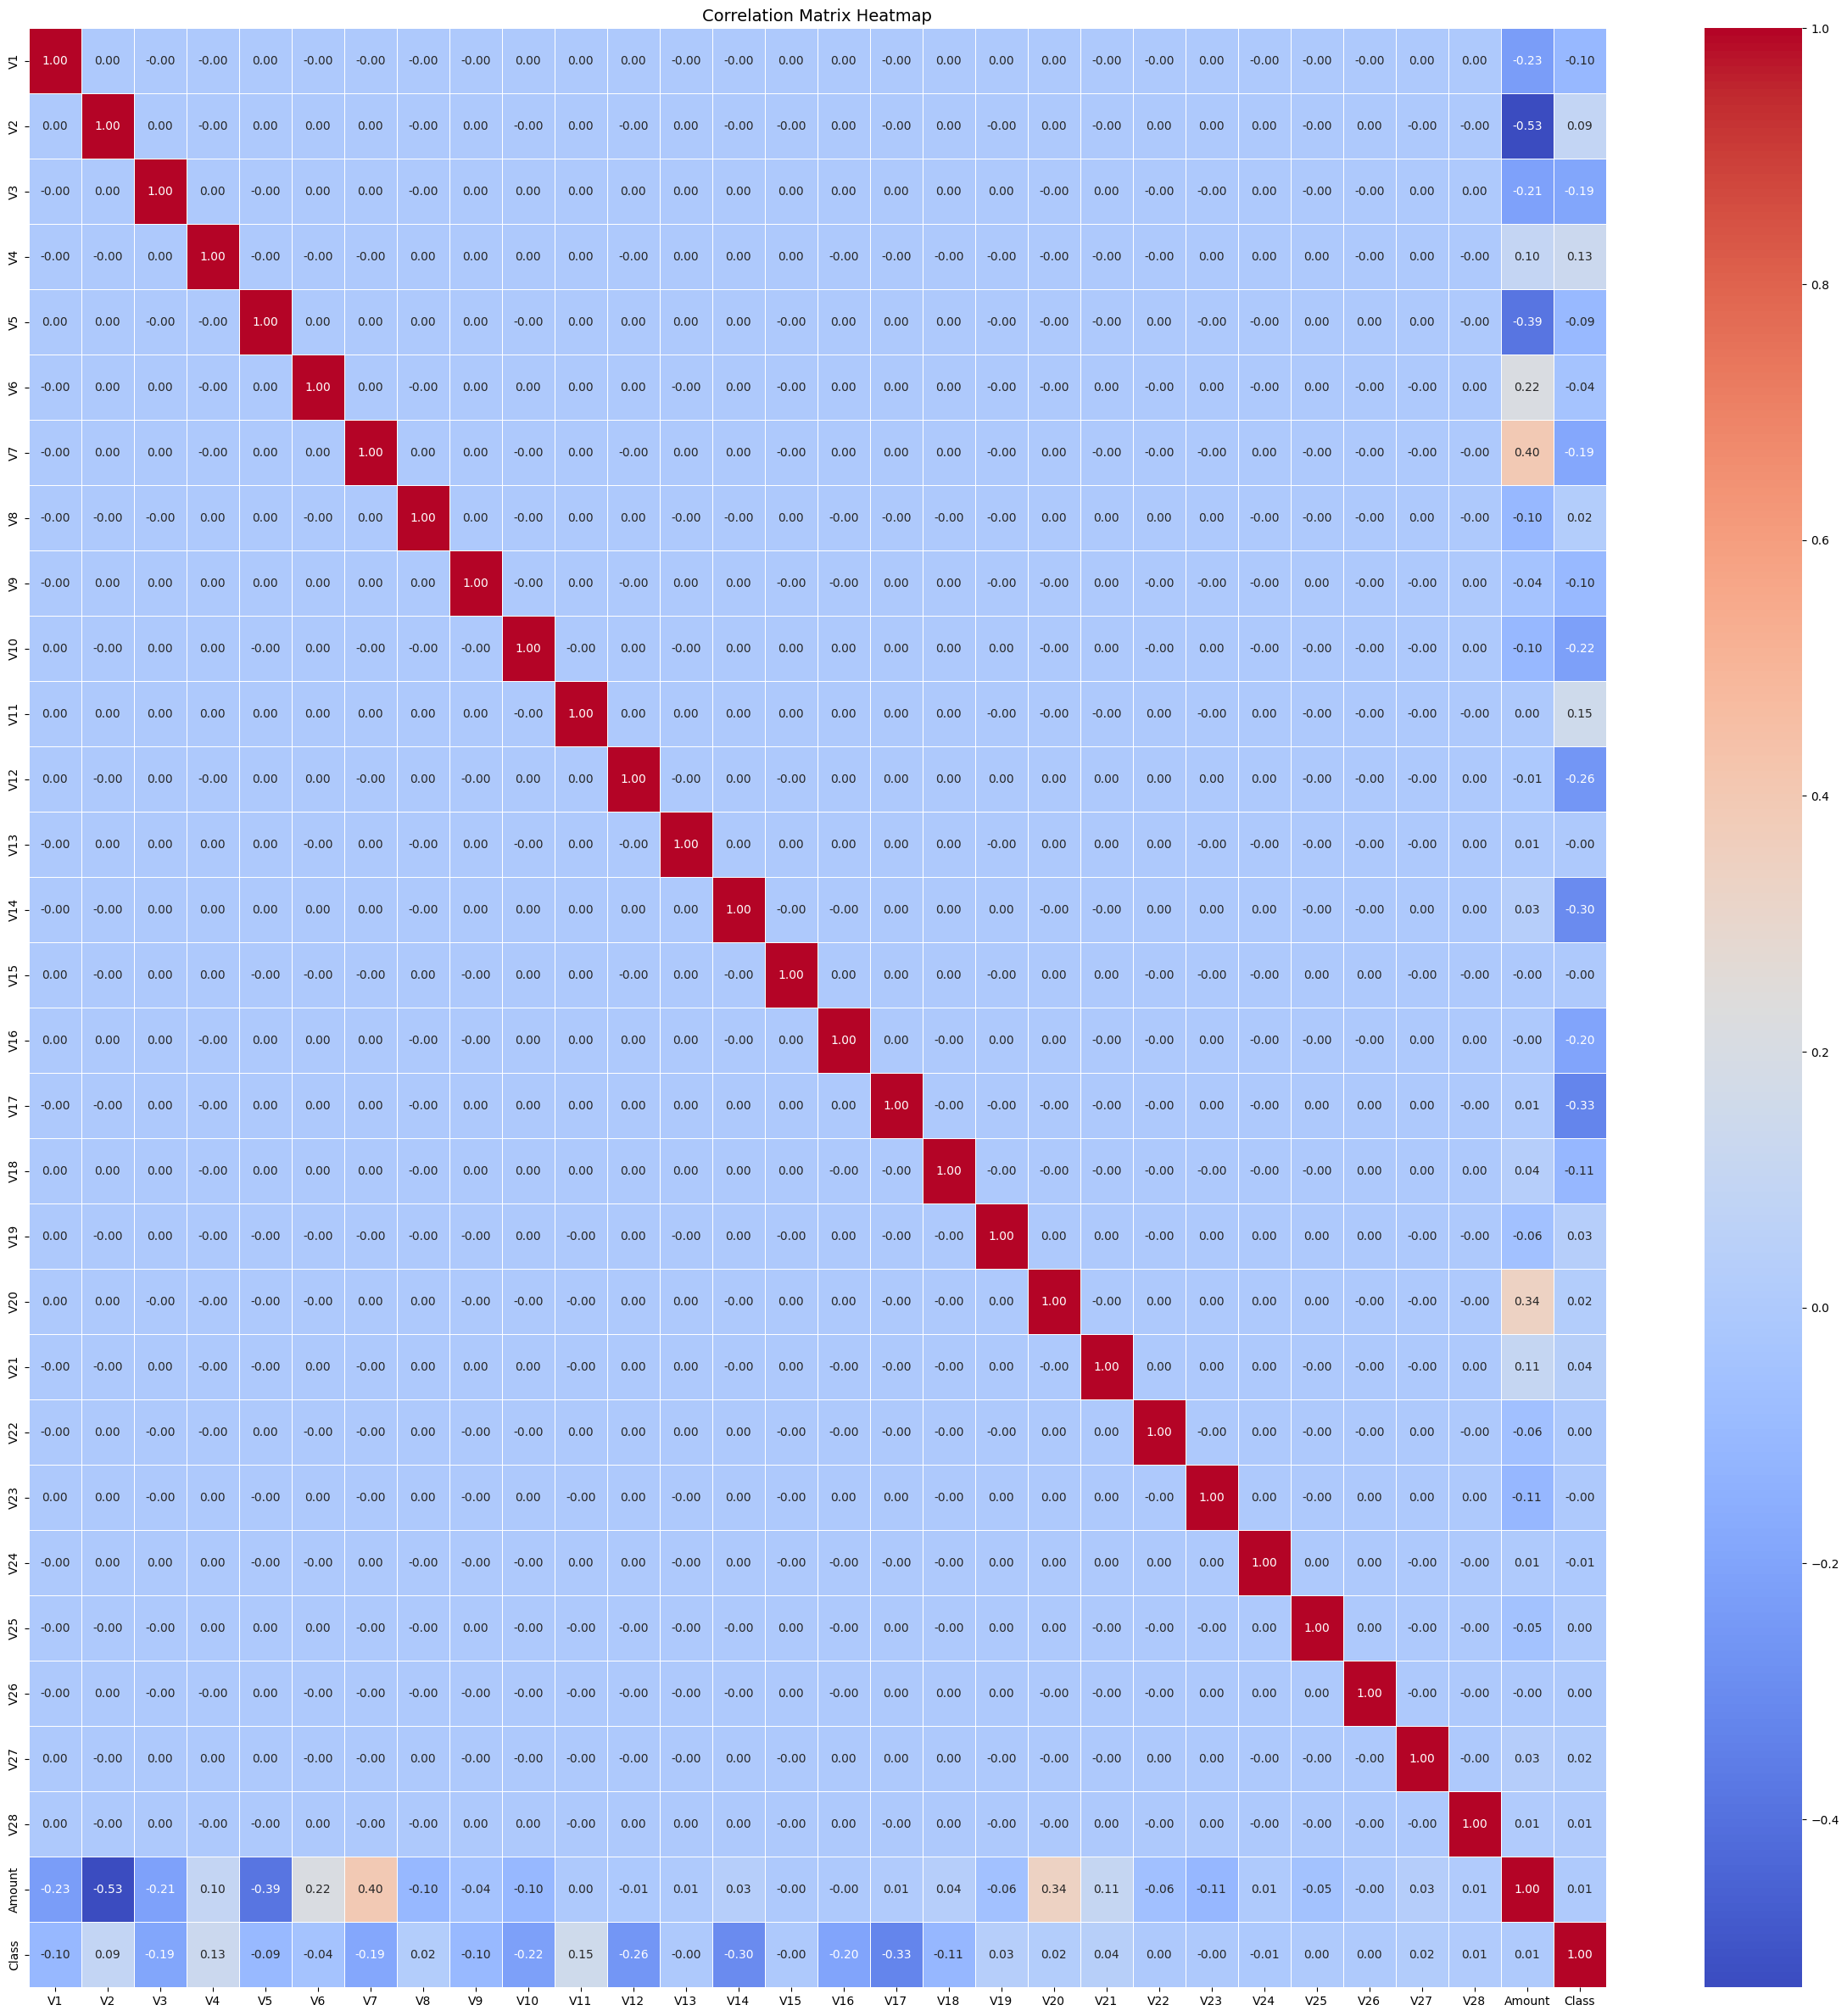

In [ ]:
# Compute correlation matrix
corr_matrix = df.corr()
# Plot heatmap
plt.figure(figsize=(30, 30))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()

In [ ]:
# Step 1: Drop target
X = df.drop(columns=["Class"])
y = df["Class"]

# Step 2: Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🚫 DO NOT reshape for ANN
# X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])  <- REMOVE THIS

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Assuming y_train contains binary labels (0 and 1)
classes = np.unique(y_train)  # Unique class labels
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
# Convert to dictionary format for model.fit()
class_weight_dict = {i: class_weights[i] for i in range(len(classes))}

**ANN**

In [ ]:
# Define ANN model
ann = Sequential([
    # Input Layer
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),  # Adjust to your feature size
    Dropout(0.3),

    # Hidden Layers
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    # Output Layer for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the model
ann.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Model summary
ann.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           3,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = ann.fit(X_train, y_train, epochs= 50, batch_size= 64, validation_data=(X_test, y_test), class_weight = class_weight_dict)

Epoch 1/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9701 - loss: 0.7587 - val_accuracy: 0.9736 - val_loss: 0.1703
Epoch 2/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9700 - loss: 0.2034 - val_accuracy: 0.9852 - val_loss: 0.0726
Epoch 3/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9638 - loss: 0.1674 - val_accuracy: 0.9819 - val_loss: 0.0802
Epoch 4/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9696 - loss: 0.1638 - val_accuracy: 0.9540 - val_loss: 0.1022
Epoch 5/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.9611 - loss: 0.1851 - val_accuracy: 0.9801 - val_loss: 0.0858
Epoch 6/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9583 - loss: 0.3427 - val_accuracy: 0.9711 - val_loss: 0.0818
Epoch 7/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9644 - loss: 0.1856 - val_accuracy: 0.9676 - val_loss: 0.0979
Epoch 8/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9534 - loss: 0

In [ ]:
y_pred_ann = ann.predict(X_test)
y_pred_ann = np.where(y_pred_ann > 0.5, 1, 0)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [ ]:
print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.92      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962



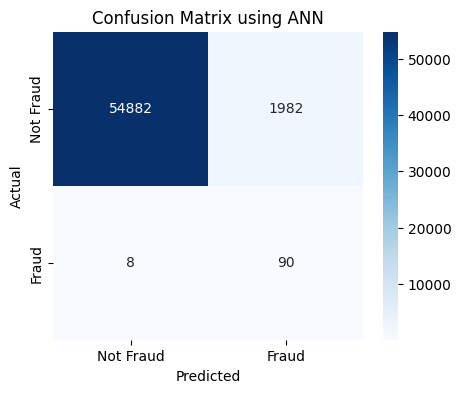

In [ ]:
cm = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix using ANN")
plt.show()

In [ ]:
# Evaluate model
loss, accuracy = ann.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9654 - loss: 0.1029
Test Accuracy: 0.9651


#########################################################

In [ ]:
# Assuming 'df' is already loaded from the provided data
X = df.drop(columns=["Class"])  # Features
y = df["Class"]  # Target variable

# Normalize the feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape data for LSTM: (samples, time_steps, features)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

**LSTM**

In [ ]:
# Define LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[2])),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])
# Compile the model
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 64)               │          24,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,025 (144.63 KB)

 Trainable params: 37,025 (144.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs= 50, batch_size= 64, validation_data=(X_test, y_test), class_weight = class_weight_dict)

Epoch 1/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.9721 - loss: 0.2624 - val_accuracy: 0.9818 - val_loss: 0.0822
Epoch 2/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.9713 - loss: 0.1520 - val_accuracy: 0.9738 - val_loss: 0.0964
Epoch 3/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.9737 - loss: 0.1010 - val_accuracy: 0.9677 - val_loss: 0.1108
Epoch 4/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9702 - loss: 0.0862 - val_accuracy: 0.9637 - val_loss: 0.1024
Epoch 5/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.9716 - loss: 0.0747 - val_accuracy: 0.9730 - val_loss: 0.0666
Epoch 6/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.9754 - loss: 0.0609 - val_accuracy: 0.9758 - val_loss: 0.0570
Epoch 7/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9783 - loss: 0.0502 - val_accuracy: 0.9727 - val_loss: 0.0537
Epoch 8/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9774 - loss: 0

In [ ]:
y_pred_lstm = model.predict(X_test)
y_pred_lstm = np.where(y_pred_lstm > 0.5, 1, 0)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [ ]:
print(classification_report(y_test, y_pred_lstm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.85      0.57        98

    accuracy                           1.00     56962
   macro avg       0.72      0.92      0.79     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9981 - loss: 0.0113
Test Accuracy: 0.9978


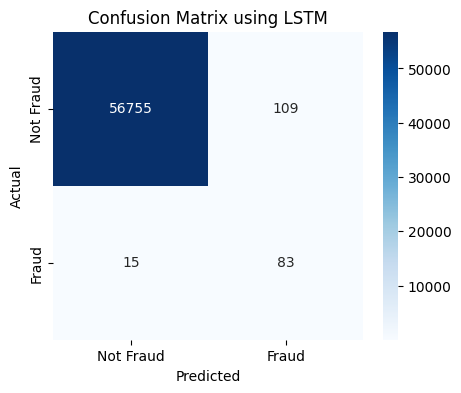

In [ ]:
cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix using LSTM")
plt.show()

**BI-LSTM**

In [ ]:
# Define Bi-LSTM Model
bl = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(1, X_train.shape[2])),
    Dropout(0.3),  # Regularization
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
bl.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
bl.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 1, 128)              │          48,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,401 (353.13 KB)

 Trainable params: 90,401 (353.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = bl.fit(X_train, y_train, epochs= 50, batch_size= 64, validation_data=(X_test, y_test), class_weight = class_weight_dict)

Epoch 1/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.9601 - loss: 0.2968 - val_accuracy: 0.9657 - val_loss: 0.1458
Epoch 2/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - accuracy: 0.9705 - loss: 0.1255 - val_accuracy: 0.9872 - val_loss: 0.0877
Epoch 3/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.9765 - loss: 0.1160 - val_accuracy: 0.9815 - val_loss: 0.0751
Epoch 4/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.9798 - loss: 0.1031 - val_accuracy: 0.9784 - val_loss: 0.0660
Epoch 5/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - accuracy: 0.9725 - loss: 0.1572 - val_accuracy: 0.9795 - val_loss: 0.0591
Epoch 6/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9697 - loss: 0.1185 - val_accuracy: 0.9763 - val_loss: 0.0562
Epoch 7/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9777 - loss: 0.0796 - val_accuracy: 0.9825 - val_loss: 0.0423
Epoch 8/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - accuracy: 0.9790 - loss

In [ ]:
y_pred_bl = bl.predict(X_test)
y_pred_bl = np.where(y_pred_bl > 0.5, 1, 0)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


In [ ]:
# Evaluate model
loss, accuracy = bl.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9953 - loss: 0.0160
Test Accuracy: 0.9949


In [ ]:
print(classification_report(y_test, y_pred_bl))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.24      0.89      0.37        98

    accuracy                           0.99     56962
   macro avg       0.62      0.94      0.69     56962
weighted avg       1.00      0.99      1.00     56962



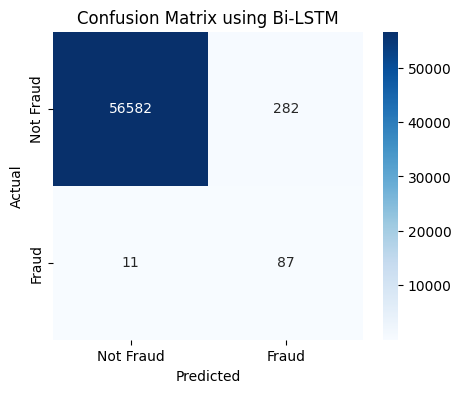

In [ ]:
cm = confusion_matrix(y_test, y_pred_bl)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix using Bi-LSTM")
plt.show()

**RANDOM FOREST CLASSIFIER**

In [ ]:
# Features and Target
X = df.drop(columns=["Class"])  # Features (V1 to V28 and Amount)
y = df["Class"]  # Target (0 or 1)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Define the Random Forest Pipeline
rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),  # Standardize data
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),  # Apply SMOTE
    ('rf', RandomForestClassifier(
        n_estimators=300,  # Number of trees
        max_depth=10,      # Maximum depth of trees
        min_samples_split=5,  # Minimum samples required to split a node
        min_samples_leaf=2,  # Minimum samples per leaf
        class_weight='balanced',  # Handle imbalance
        random_state=42
    ))
])

# Train the Random Forest Pipeline
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=300, random_state=42))])

In [ ]:
# Predictions for Random Forest
y_pred_rf = rf_pipeline.predict(X_test)
# Evaluation for Random Forest
print("\n Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


 Random Forest Results:
Accuracy: 0.9979108879603946
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.44      0.86      0.59        98

    accuracy                           1.00     56962
   macro avg       0.72      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962



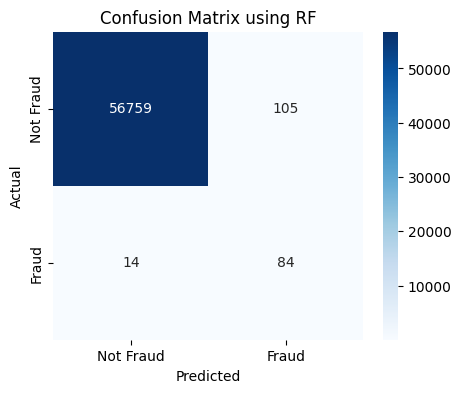

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix using RF")
plt.show()

**LightGBM**

In [ ]:
# Define the LightGBM Pipeline
lgbm_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),  # Standardize data
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),  # Apply SMOTE
    ('lgbm', LGBMClassifier(
        n_estimators=300,  # Number of trees
        learning_rate=0.05,  # Step size shrinkage
        max_depth=10,  # Maximum depth
        num_leaves=31,  # Number of leaves in one tree
        subsample=0.8,  # Fraction of samples per tree
        colsample_bytree=0.8,  # Fraction of features per tree
        reg_lambda=1,  # L2 regularization
        reg_alpha=0,  # L1 regularization
        class_weight='balanced',  # Handle class imbalance
        random_state=42
    ))
])
# Train the LightGBM Pipeline
lgbm_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 113725, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.110903 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 341176, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
                ('lgbm',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
                                learning_rate=0.05, max_depth=10,
                                n_estimators=300, random_state=42, reg_alpha=0,
                                reg_lambda=1, subsample=0.8))])

In [ ]:
# Predictions for LightGBM
y_pred_lgbm = lgbm_pipeline.predict(X_test)
# Evaluation for LightGBM
print("\n LightGBM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Classification Report:\n", classification_report(y_test, y_pred_lgbm))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



 LightGBM Results:
Accuracy: 0.99875355500158
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.59      0.88      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.85     56962
weighted avg       1.00      1.00      1.00     56962



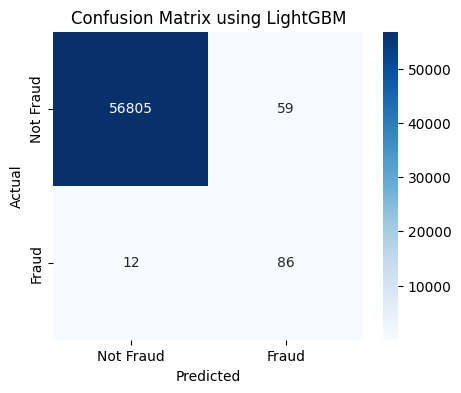

In [ ]:
cm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix using LightGBM")
plt.show()

**XGBOOST MODEL**

In [ ]:
# Define the Pipeline
xg_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),  # Standardize data
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),  # Apply SMOTE
    ('xgb', XGBClassifier(
        n_estimators=300,       # Number of trees
        learning_rate=0.05,     # Step size shrinkage
        max_depth=6,            # Maximum depth of trees
        min_child_weight=1,     # Minimum sum of instance weight (hessian) needed in a child
        subsample=0.8,          # Fraction of samples used per tree
        colsample_bytree=0.8,   # Fraction of features used per tree
        gamma=0,                # Minimum loss reduction for split
        reg_lambda=1,           # L2 regularization
        reg_alpha=0,            # L1 regularization
        objective='binary:logistic',  # Binary classification
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ))
])

# Train the Pipeline
xg_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:21:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=42, ...))])

In [ ]:
# Predictions
y_pred_xg = xg_pipeline.predict(X_test)
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("Classification Report:\n", classification_report(y_test, y_pred_xg))

Accuracy: 0.998735999438222
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.59      0.88      0.70        98

    accuracy                           1.00     56962
   macro avg       0.79      0.94      0.85     56962
weighted avg       1.00      1.00      1.00     56962



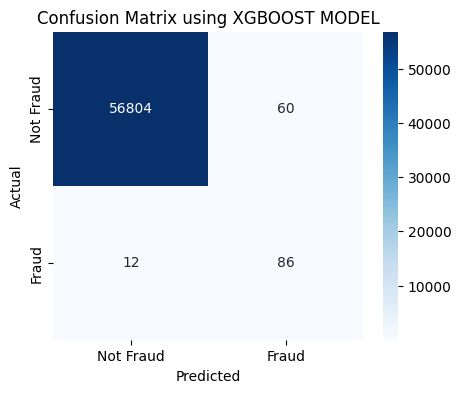

In [ ]:
cm = confusion_matrix(y_test, y_pred_xg)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix using XGBOOST MODEL")
plt.show()

**ENSEMBLE MODEL**

In [ ]:
from sklearn.ensemble import VotingClassifier

In [ ]:
# Define individual models
xgb_clf = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31, random_state=42)
# Create an ensemble VotingClassifier
ensemble_clf = VotingClassifier(
    estimators=[('xgb', xgb_clf), ('rf', rf_clf), ('lgb', lgb_clf)],
    voting='soft'  # Soft voting to use probability estimates
)
# Train the ensemble model
ensemble_clf.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learni...
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('rf',
                              RandomForestClassifier(max_depth=10,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('lgb',
                              LGBMClassifier(n_estimators=200,
                                             random_state=42))],
                 voting='soft')

In [ ]:
# Predict on test set
y_pred_en = ensemble_clf.predict(X_test)
# Evaluation for Random Forest
print("\n Ensemble Model Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_en))
print("Classification Report:\n", classification_report(y_test, y_pred_en))


 Ensemble Model Results:
Accuracy: 0.9995611109160493
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



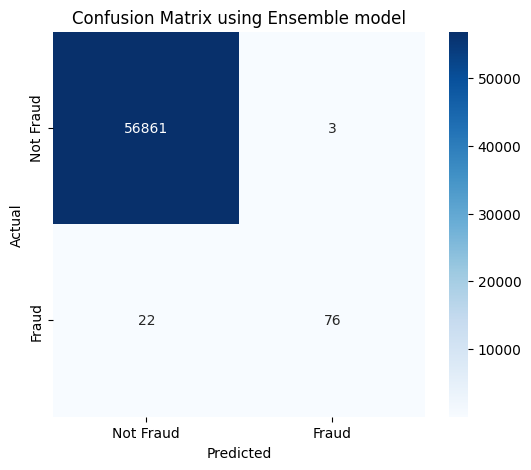

In [ ]:
cm = confusion_matrix(y_test, y_pred_en)
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix using Ensemble model")
plt.show()

**COMPARATIVE PERFORMANCE PLOTS**

<ipython-input-46-7ca39cd9cab0>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


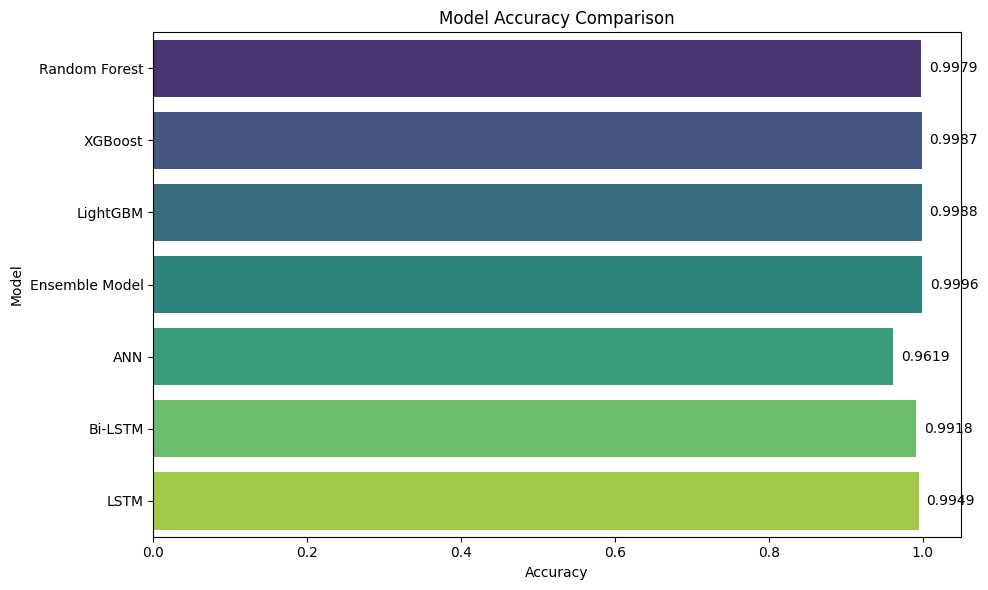

In [ ]:
# Calculate accuracy for each model
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xg)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
acc_en = accuracy_score(y_test, y_pred_en)
acc_ann = accuracy_score(y_test, y_pred_ann)
acc_bi = accuracy_score(y_test, y_pred_bl)
acc_lstm = accuracy_score(y_test, y_pred_lstm)
acc_ann = accuracy_score(y_test, y_pred_ann)
# Create a dictionary with model names and corresponding accuracy values
accuracy_dict = {
    'Random Forest': acc_rf,
    'XGBoost': acc_xgb,
    'LightGBM': acc_lgbm,
    'Ensemble Model': acc_en,
    'ANN': acc_ann,
    'Bi-LSTM': acc_bi,
    'LSTM': acc_lstm
    }
# Convert dictionary to DataFrame for easy plotting
accuracy_df = pd.DataFrame(list(accuracy_dict.items()), columns=['Model', 'Accuracy'])
# Create a barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
# Add the accuracy values on top of the bars
for index, value in enumerate(accuracy_df['Accuracy']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center')
# Set labels and title
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Model Accuracy Comparison')
# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

<ipython-input-48-1097a206cfac>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC-ROC', y='Model', data=auc_df, palette='Purples_r')


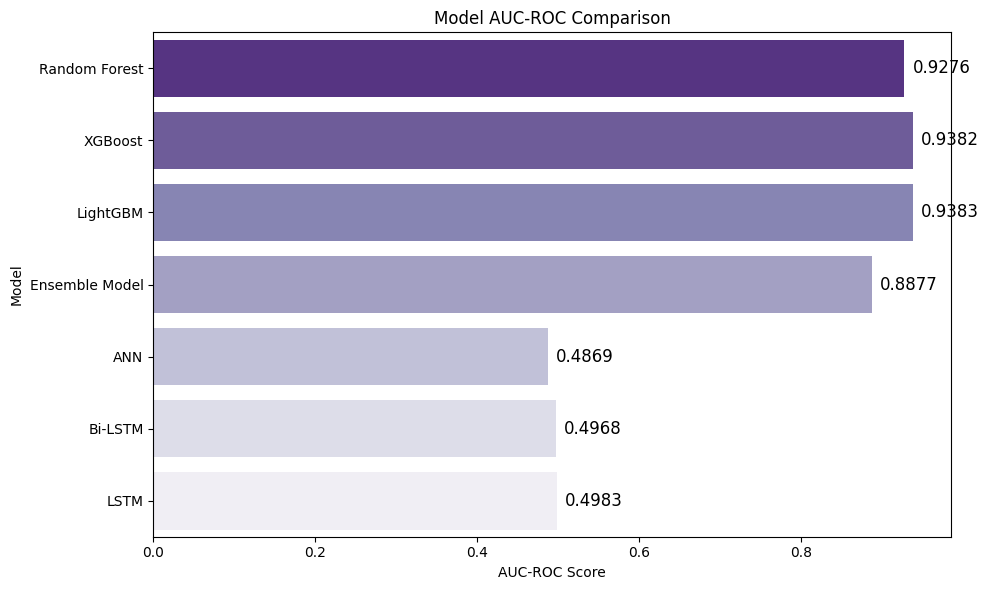

In [ ]:
# Compute AUC-ROC scores
auc_roc_scores = {
    'Random Forest': roc_auc_score(y_test, y_pred_rf, average='macro'),
    'XGBoost': roc_auc_score(y_test, y_pred_xg, average='macro'),
    'LightGBM': roc_auc_score(y_test, y_pred_lgbm, average='macro'),
    'Ensemble Model': roc_auc_score(y_test, y_pred_en, average='macro'),
    'ANN': roc_auc_score(y_test, y_pred_ann, average='macro'),
    'Bi-LSTM': roc_auc_score(y_test, y_pred_bl, average='macro'),
    'LSTM': roc_auc_score(y_test, y_pred_lstm, average='macro')
}

# Convert to DataFrame
auc_df = pd.DataFrame(list(auc_roc_scores.items()), columns=['Model', 'AUC-ROC'])

# Create AUC-ROC bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='AUC-ROC', y='Model', data=auc_df, palette='Purples_r')

# Add values on bars
for index, value in enumerate(auc_df['AUC-ROC']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=12)

# Labels and title
plt.xlabel('AUC-ROC Score')
plt.ylabel('Model')
plt.title('Model AUC-ROC Comparison')
plt.tight_layout()
plt.show()

<ipython-input-49-8720afcda5c4>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Score', y='Model', data=f1_df, palette='Oranges_r')


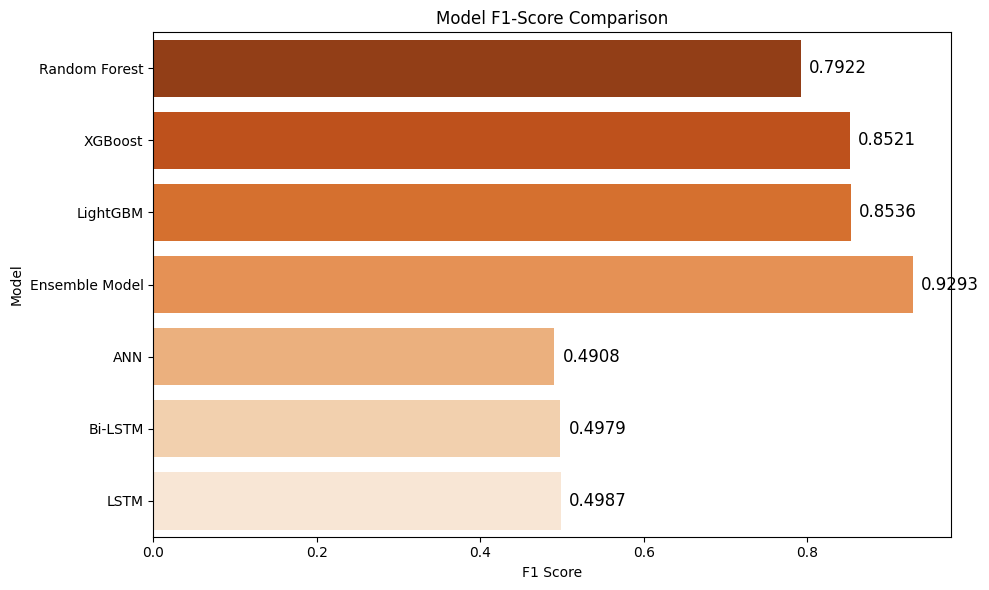

In [ ]:
from sklearn.metrics import f1_score

# Compute F1 scores
f1_scores = {
    'Random Forest': f1_score(y_test, y_pred_rf, average='macro'),
    'XGBoost': f1_score(y_test, y_pred_xg, average='macro'),
    'LightGBM': f1_score(y_test, y_pred_lgbm, average='macro'),
    'Ensemble Model': f1_score(y_test, y_pred_en, average='macro'),
    'ANN': f1_score(y_test, y_pred_ann, average='macro'),
    'Bi-LSTM': f1_score(y_test, y_pred_bl, average='macro'),
    'LSTM': f1_score(y_test, y_pred_lstm, average='macro')
}

# Convert to DataFrame
f1_df = pd.DataFrame(list(f1_scores.items()), columns=['Model', 'F1-Score'])

# Create F1-score bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Model', data=f1_df, palette='Oranges_r')

# Add values on bars
for index, value in enumerate(f1_df['F1-Score']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=12)

# Labels and title
plt.xlabel('F1 Score')
plt.ylabel('Model')
plt.title('Model F1-Score Comparison')
plt.tight_layout()
plt.show()

<ipython-input-50-801dd63213b6>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Precision', y='Model', data=precision_df, palette='Blues_r')


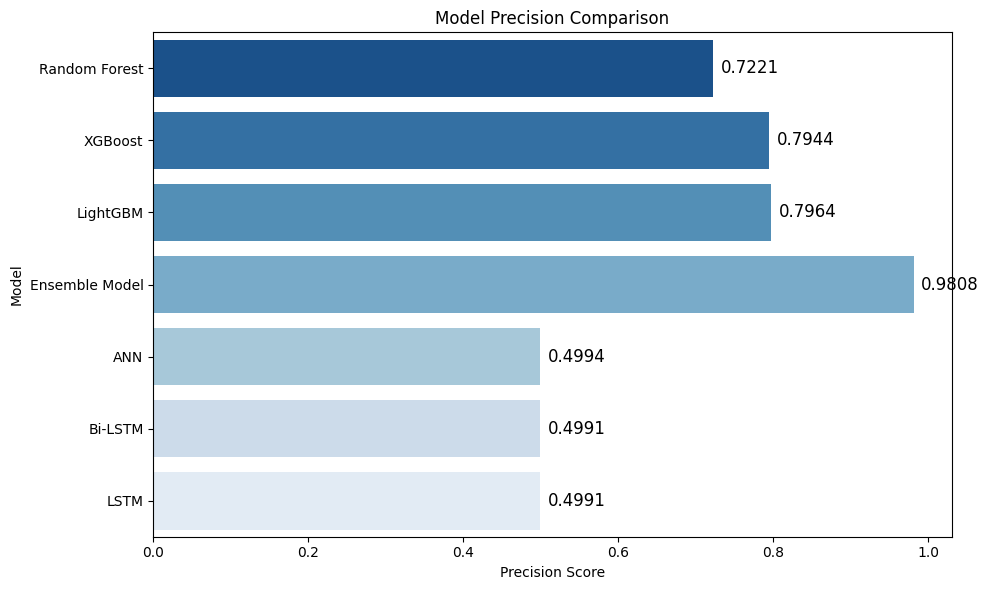

In [ ]:
from sklearn.metrics import precision_score

# Compute precision scores
prec_scores = {
    'Random Forest': precision_score(y_test, y_pred_rf, average='macro'),
    'XGBoost': precision_score(y_test, y_pred_xg, average='macro'),
    'LightGBM': precision_score(y_test, y_pred_lgbm, average='macro'),
    'Ensemble Model': precision_score(y_test, y_pred_en, average='macro'),
    'ANN': precision_score(y_test, y_pred_ann, average='macro'),
    'Bi-LSTM': precision_score(y_test, y_pred_bl, average='macro'),
    'LSTM': precision_score(y_test, y_pred_lstm, average='macro')
}

# Convert to DataFrame
precision_df = pd.DataFrame(list(prec_scores.items()), columns=['Model', 'Precision'])

# Create Precision bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Precision', y='Model', data=precision_df, palette='Blues_r')

# Add values on bars
for index, value in enumerate(precision_df['Precision']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=12)

# Labels and title
plt.xlabel('Precision Score')
plt.ylabel('Model')
plt.title('Model Precision Comparison')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import recall_score

<ipython-input-52-ddf977b25091>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recall', y='Model', data=recall_df, palette='viridis')


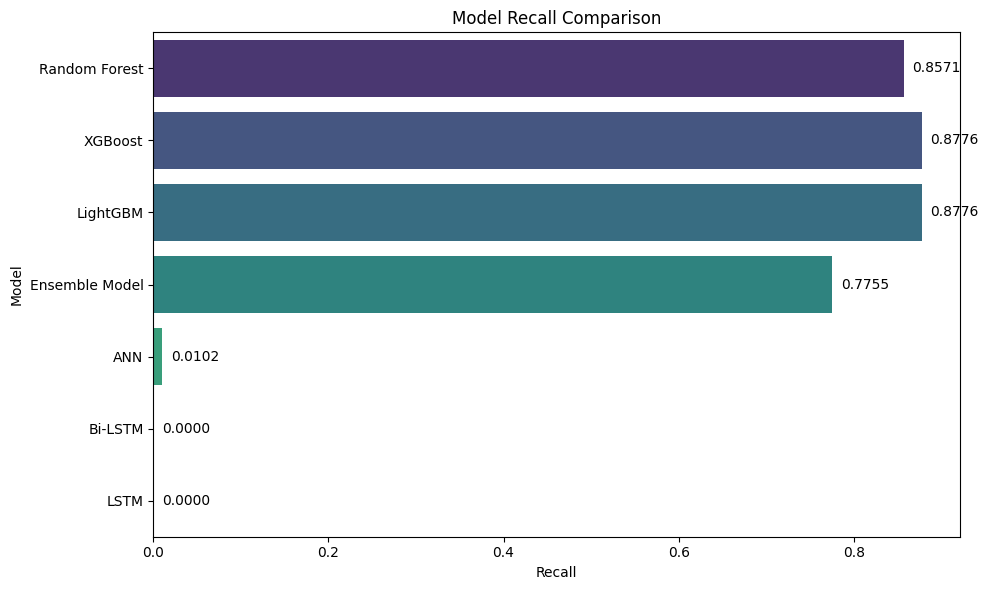

In [ ]:
# Calculate recall for each model
recall_rf = recall_score(y_test, y_pred_rf)
recall_xgb = recall_score(y_test, y_pred_xg)
recall_lgbm = recall_score(y_test, y_pred_lgbm)
recall_en = recall_score(y_test, y_pred_en)
recall_ann = recall_score(y_test, y_pred_ann)
recall_bi = recall_score(y_test, y_pred_bl)
recall_lstm = recall_score(y_test, y_pred_lstm)

# Create a dictionary with model names and corresponding recall values
recall_dict = {
    'Random Forest': recall_rf,
    'XGBoost': recall_xgb,
    'LightGBM': recall_lgbm,
    'Ensemble Model': recall_en,
    'ANN': recall_ann,
    'Bi-LSTM': recall_bi,
    'LSTM': recall_lstm
}

# Convert dictionary to DataFrame for easy plotting
recall_df = pd.DataFrame(list(recall_dict.items()), columns=['Model', 'Recall'])

# Create a barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Recall', y='Model', data=recall_df, palette='viridis')

# Add the recall values on top of the bars
for index, value in enumerate(recall_df['Recall']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center')

# Set labels and title
plt.xlabel('Recall')
plt.ylabel('Model')
plt.title('Model Recall Comparison')

# Show the plot
plt.tight_layout()
plt.show()